In [44]:
# 1. Import och inläsning
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.spatial.distance import cdist
from scipy.stats import spearmanr, pearsonr

data_dir = "db_29_3_text"
occ = pd.read_csv(os.path.join(data_dir, "Occupation Data.txt"), sep='\t', encoding='utf-8')
skills = pd.read_csv(os.path.join(data_dir, "Skills.txt"), sep='\t', encoding='utf-8')
abilities = pd.read_csv(os.path.join(data_dir, "Abilities.txt"), sep='\t', encoding='utf-8')
rel = pd.read_csv(os.path.join(data_dir, "Related Occupations.txt"), sep='\t', encoding='utf-8')


In [45]:
# 2. Skapa matriser för skills och abilities
skills_lv = skills[skills['Scale ID'] == 'LV']
skills_im = skills[skills['Scale ID'] == 'IM']

abilities_lv = abilities[abilities['Scale ID'] == 'LV']
abilities_im = abilities[abilities['Scale ID'] == 'IM']

lv_skill_matrix = skills_lv.pivot(index='O*NET-SOC Code', columns='Element ID', values='Data Value')
im_skill_matrix = skills_im.pivot(index='O*NET-SOC Code', columns='Element ID', values='Data Value')
lv_abil_matrix = abilities_lv.pivot(index='O*NET-SOC Code', columns='Element ID', values='Data Value')
im_abil_matrix = abilities_im.pivot(index='O*NET-SOC Code', columns='Element ID', values='Data Value')

lv_skill_matrix = lv_skill_matrix.reindex(im_skill_matrix.index)
lv_abil_matrix = lv_abil_matrix.reindex(im_abil_matrix.index)


In [46]:
# 3. PCA och occupation space per domän
def build_domain_df(lv_matrix, im_matrix, occ, domain_name):
    pca = PCA(n_components=2)
    coords = pca.fit_transform(im_matrix.fillna(0).values)
    xi = np.arctan2(coords[:, 1], coords[:, 0]) % (2 * np.pi)
    lv_weighted = (lv_matrix * im_matrix).sum(axis=1) / im_matrix.sum(axis=1)
    chi = (lv_weighted - lv_weighted.min()) / (lv_weighted.max() - lv_weighted.min())
    occ_titles = occ.set_index('O*NET-SOC Code').reindex(im_matrix.index)['Title']
    return pd.DataFrame({
        'onet_code': im_matrix.index,
        'xi': xi,
        'chi': chi.values,
        'domain': domain_name,
        'title': occ_titles.values
    })

df_skills = build_domain_df(lv_skill_matrix, im_skill_matrix, occ, 'Skills')
df_abilities = build_domain_df(lv_abil_matrix, im_abil_matrix, occ, 'Abilities')
df_plot = pd.concat([df_skills, df_abilities], ignore_index=True)


In [47]:
df_plot = pd.concat([df_skills, df_abilities], ignore_index=True)

# Beräkna gemensam tyngdpunkt och lägg till xi_rot
x = df_plot['chi'] * np.cos(df_plot['xi'])
y = df_plot['chi'] * np.sin(df_plot['xi'])
x_center = x.mean()
y_center = y.mean()
center_angle = np.arctan2(y_center, x_center) % (2 * np.pi)
df_plot['xi_rot'] = (df_plot['xi'] - center_angle) % (2 * np.pi)

# Lägg till xi_rot även till domänvisa DataFrames, annars fungerar inte avståndsanalys:
df_skills['xi_rot'] = (df_skills['xi'] - center_angle) % (2 * np.pi)
df_abilities['xi_rot'] = (df_abilities['xi'] - center_angle) % (2 * np.pi)


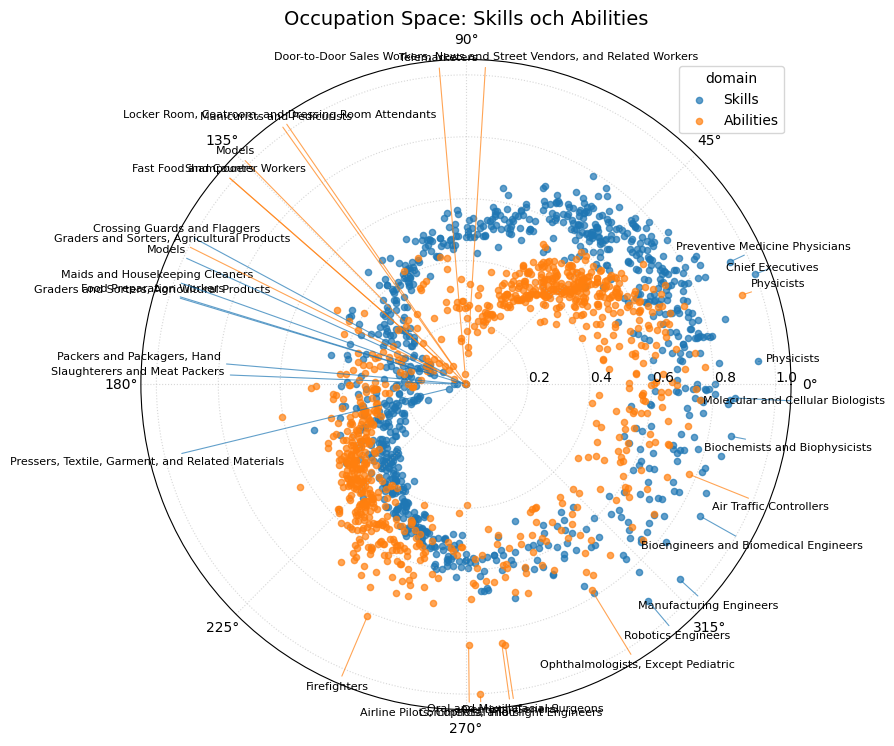

(<Figure size 900x900 with 1 Axes>,
 <PolarAxes: title={'center': 'Occupation Space: Skills och Abilities'}>)

In [48]:
# 5. Polär plotfunktion med annotering och linjer
def plot_occupation_space_domains(
    df,
    chi_col='chi',
    xi_col='xi_rot',
    domain_col='domain',
    color_map=None,
    annotate_n=8,
    figsize=(9,9),
    title=None,
    alpha=0.7
):
    unique_domains = df[domain_col].unique()
    if color_map is None:
        colors = plt.cm.tab10.colors
        color_map = {dom: colors[i % len(colors)] for i, dom in enumerate(unique_domains)}
    fig, ax = plt.subplots(figsize=figsize, subplot_kw={'projection':'polar'})
    for dom in unique_domains:
        mask = df[domain_col] == dom
        ax.scatter(df.loc[mask, xi_col], df.loc[mask, chi_col],
                   color=color_map[dom], alpha=alpha, s=20, label=dom)
    chi_label = 1.06
    for dom in unique_domains:
        mask = df[domain_col] == dom
        sub = df.loc[mask]
        idx_max = sub[chi_col].nlargest(annotate_n).index
        idx_min = sub[chi_col].nsmallest(annotate_n).index
        idxs = pd.Index(idx_max.tolist() + idx_min.tolist()).unique()
        annots = sub.loc[idxs]
        for _, row in annots.iterrows():
            angle = row[xi_col]
            ax.annotate(
                row.get('title', row.get('onet_code', '')),
                xy=(angle, row[chi_col]),
                xytext=(angle, chi_label),
                textcoords='data',
                ha='center', va='center',
                fontsize=8,
                rotation=0,
                arrowprops=dict(arrowstyle='-', lw=0.8, color=color_map[dom], alpha=0.7)
            )
    ax.set_rlabel_position(0)
    ax.grid(True, linestyle=':', alpha=0.5)
    ax.set_theta_zero_location('E')
    ax.set_theta_direction(1)
    ax.legend(loc='upper right', fontsize=10, title=domain_col)
    if title:
        ax.set_title(title, fontsize=14)
    plt.tight_layout()
    plt.show()
    return fig, ax

# Plot
plot_occupation_space_domains(
    df_plot,
    chi_col='chi',
    xi_col='xi_rot',
    domain_col='domain',
    annotate_n=8,
    title='Occupation Space: Skills och Abilities'
)


In [49]:
# 6. Närhets- och korrelationsanalys PER DOMÄN

def ocs_near_correlation(df_domain, rel, domain_label):
    # 1. Kartesiska koordinater
    df_domain = df_domain.copy()
    df_domain['x'] = df_domain['chi'] * np.cos(df_domain['xi_rot'])
    df_domain['y'] = df_domain['chi'] * np.sin(df_domain['xi_rot'])
    code2xy = df_domain.set_index('onet_code')[['x', 'y']].to_dict('index')
    # 2. Avstånd för varje rad i rel
    def occs_distance(row):
        code1 = row['O*NET-SOC Code']
        code2 = row['Related O*NET-SOC Code']
        xy1 = code2xy.get(code1)
        xy2 = code2xy.get(code2)
        if xy1 is not None and xy2 is not None:
            return np.sqrt((xy1['x'] - xy2['x'])**2 + (xy1['y'] - xy2['y'])**2)
        else:
            return np.nan
    rel[f'ocs_distance_{domain_label}'] = rel.apply(occs_distance, axis=1)
    # 3. Bygg närhetsrank
    coords = df_domain[['x', 'y']].values
    codes = df_domain['onet_code'].values
    dist_matrix = cdist(coords, coords)
    nearest_ranks = {}
    for i, code in enumerate(codes):
        dists = dist_matrix[i]
        sorted_indices = np.argsort(dists)
        sorted_codes = codes[sorted_indices]
        nearest_ranks[code] = {other_code: rank for rank, other_code in enumerate(sorted_codes)}
    rel[f'ocs_rank_{domain_label}'] = rel.apply(
        lambda row: nearest_ranks.get(row['O*NET-SOC Code'], {}).get(row['Related O*NET-SOC Code'], np.nan),
        axis=1
    )
    # 4. Korrelation
    mask = rel[f'ocs_distance_{domain_label}'].notna() & rel[f'ocs_rank_{domain_label}'].notna()
    x = rel.loc[mask, f'ocs_rank_{domain_label}']
    y = rel.loc[mask, f'ocs_distance_{domain_label}']
    spearman = spearmanr(x, y)
    pearson = pearsonr(x, y)
    print(f"\n==== {domain_label} ====")
    print('Spearman rangkorrelation:', spearman)
    print('Pearson korrelation:', pearson)
    return rel

# Kör analysen för båda domänerna:
rel = ocs_near_correlation(df_skills, rel, 'skills')
rel = ocs_near_correlation(df_abilities, rel, 'abilities')



==== skills ====
Spearman rangkorrelation: SignificanceResult(statistic=np.float64(0.9403020848480903), pvalue=np.float64(0.0))
Pearson korrelation: PearsonRResult(statistic=np.float64(0.9497404631101989), pvalue=np.float64(0.0))

==== abilities ====
Spearman rangkorrelation: SignificanceResult(statistic=np.float64(0.9055953154491507), pvalue=np.float64(0.0))
Pearson korrelation: PearsonRResult(statistic=np.float64(0.939569131708477), pvalue=np.float64(0.0))
